In [1]:
!rm -rf SCM_UNet

In [2]:
!git clone https://github.com/malavikaPrasad11/SCM_UNet.git

Cloning into 'SCM_UNet'...
remote: Enumerating objects: 18, done.
remote: Counting objects: 100% (18/18), done.
remote: Compressing objects: 100% (13/13), done.
remote: Total 18 (delta 5), reused 17 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (18/18), 20.65 KiB | 2.95 MiB/s, done.
Resolving deltas: 100% (5/5), done.


In [3]:
%cd /kaggle/working/SCM_UNet
!ls -la

/kaggle/working/SCM_UNet
total 84
drwxr-xr-x 3 root root  4096 Aug 12 14:08 .
drwxr-xr-x 4 root root  4096 Aug 12 14:08 ..
-rw-r--r-- 1 root root  7274 Aug 12 14:08 dataset.py
-rw-r--r-- 1 root root  3129 Aug 12 14:08 eval.py
drwxr-xr-x 8 root root  4096 Aug 12 14:08 .git
-rw-r--r-- 1 root root  5210 Aug 12 14:08 INSTRUCTIONS.md
-rw-r--r-- 1 root root  1043 Aug 12 14:08 losses.py
-rw-r--r-- 1 root root  2534 Aug 12 14:08 metrics.py
-rw-r--r-- 1 root root 23045 Aug 12 14:08 model.py
-rw-r--r-- 1 root root  7762 Aug 12 14:08 README.md
-rw-r--r-- 1 root root    25 Aug 12 14:08 requirements.txt
-rw-r--r-- 1 root root  7578 Aug 12 14:08 train.py


In [4]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    level = root.replace("/kaggle/input", "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    for file in files[:10]:
        print(f"{indent} {file}")

input/
  datasets/
    tschandl/
      isic2018-challenge-task1-data-segmentation/
        ISIC2018_Task1-2_Training_Input/
         ISIC_0012706.jpg
         ISIC_0010192.jpg
         ISIC_0010017.jpg
         ISIC_0013000.jpg
         ISIC_0013166.jpg
         ISIC_0003308.jpg
         ISIC_0012332.jpg
         ISIC_0014291.jpg
         ISIC_0014729.jpg
         ISIC_0000012.jpg
        ISIC2018_Task1_Training_GroundTruth/
         ISIC_0000505_segmentation.png
         ISIC_0015129_segmentation.png
         ISIC_0014743_segmentation.png
         ISIC_0000057_segmentation.png
         ISIC_0015211_segmentation.png
         ISIC_0012880_segmentation.png
         ISIC_0005555_segmentation.png
         ISIC_0012379_segmentation.png
         ISIC_0000226_segmentation.png
         ISIC_0014233_segmentation.png
        ISIC2018_Task1-2_Test_Input/
         ISIC_0036343.jpg
         ISIC_0023300.jpg
         ISIC_0019816.jpg
         ISIC_0017411.jpg
         ISIC_0020619.jpg
         ISIC_

In [6]:
import os

base = "/kaggle/input/datasets/tschandl/isic2018-challenge-task1-data-segmentation"

for item in os.listdir(base):
    path = os.path.join(base, item)
    if os.path.isdir(path):
        print(item)

ISIC2018_Task1-2_Training_Input
ISIC2018_Task1_Training_GroundTruth
ISIC2018_Task1-2_Test_Input
ISIC2018_Task1-2_Validation_Input


In [8]:
import os

for root, dirs, files in os.walk(base):
    if "GroundTruth" in root:
        print(root)
        print(files[:10])

/kaggle/input/datasets/tschandl/isic2018-challenge-task1-data-segmentation/ISIC2018_Task1_Training_GroundTruth
['ISIC_0000505_segmentation.png', 'ISIC_0015129_segmentation.png', 'ISIC_0014743_segmentation.png', 'ISIC_0000057_segmentation.png', 'ISIC_0015211_segmentation.png', 'ISIC_0012880_segmentation.png', 'ISIC_0005555_segmentation.png', 'ISIC_0012379_segmentation.png', 'ISIC_0000226_segmentation.png', 'ISIC_0014233_segmentation.png']


In [9]:
import os

base = "/kaggle/input/datasets/tschandl/isic2018-challenge-task1-data-segmentation"

print("Contents of dataset:")
for item in os.listdir(base):
    path = os.path.join(base, item)
    print(item, "->", "DIR" if os.path.isdir(path) else "FILE")

Contents of dataset:
ISIC2018_Task1-2_Training_Input -> DIR
ISIC2018_Task1_Training_GroundTruth -> DIR
ISIC2018_Task1-2_Test_Input -> DIR
ISIC2018_Task1-2_Validation_Input -> DIR


In [10]:
import os

base = "/kaggle/input/datasets/tschandl/isic2018-challenge-task1-data-segmentation"

mask_dir = os.path.join(
    base,
    "ISIC2018_Task1_Training_GroundTruth"
)

print("Number of masks:", len(os.listdir(mask_dir)))
print("First 10 masks:")

for f in sorted(os.listdir(mask_dir))[:10]:
    print(f)

Number of masks: 2596
First 10 masks:
ATTRIBUTION.txt
ISIC_0000000_segmentation.png
ISIC_0000001_segmentation.png
ISIC_0000003_segmentation.png
ISIC_0000004_segmentation.png
ISIC_0000006_segmentation.png
ISIC_0000007_segmentation.png
ISIC_0000008_segmentation.png
ISIC_0000009_segmentation.png
ISIC_0000011_segmentation.png


In [11]:
import os
import random
import shutil

BASE = "/kaggle/input/datasets/tschandl/isic2018-challenge-task1-data-segmentation"

IMAGE_DIR = os.path.join(
    BASE,
    "ISIC2018_Task1-2_Training_Input"
)

MASK_DIR = os.path.join(
    BASE,
    "ISIC2018_Task1_Training_GroundTruth"
)

OUTPUT = "/kaggle/working/ISIC2018_small"

OUT_IMAGE_DIR = os.path.join(OUTPUT, "images")
OUT_MASK_DIR = os.path.join(OUTPUT, "masks")

os.makedirs(OUT_IMAGE_DIR, exist_ok=True)
os.makedirs(OUT_MASK_DIR, exist_ok=True)

# Get only actual image files
images = [
    f for f in os.listdir(IMAGE_DIR)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

print("Total available images:", len(images))

# Fixed seed so we get the same subset every time
random.seed(42)
random.shuffle(images)

# Take only 500 images
selected_images = images[:500]

copied = 0
missing = []

for img_name in selected_images:

    stem = os.path.splitext(img_name)[0]

    # Corresponding ISIC segmentation mask
    mask_name = stem + "_segmentation.png"

    img_path = os.path.join(IMAGE_DIR, img_name)
    mask_path = os.path.join(MASK_DIR, mask_name)

    if not os.path.exists(mask_path):
        missing.append(img_name)
        continue

    shutil.copy2(
        img_path,
        os.path.join(OUT_IMAGE_DIR, img_name)
    )

    shutil.copy2(
        mask_path,
        os.path.join(OUT_MASK_DIR, mask_name)
    )

    copied += 1

print("Selected:", len(selected_images))
print("Successfully copied:", copied)
print("Missing masks:", len(missing))

if missing:
    print("Missing examples:", missing[:10])

Total available images: 2594
Selected: 500
Successfully copied: 500
Missing masks: 0


In [13]:
print(
    "Images:",
    len(os.listdir("/kaggle/working/ISIC2018_small/images"))
)

print(
    "Masks:",
    len(os.listdir("/kaggle/working/ISIC2018_small/masks"))
)

Images: 500
Masks: 500


In [14]:
from dataset import build_datasets

root = "/kaggle/working/ISIC2018_small"

train_ds, val_ds, test_ds = build_datasets(
    root,
    img_size=256,
    val_ratio=0.1,
    test_ratio=0.2,
    seed=42
)

print("Train:", len(train_ds))
print("Validation:", len(val_ds))
print("Test:", len(test_ds))

Train: 350
Validation: 50
Test: 100


Image shape: torch.Size([3, 256, 256])
Mask shape: torch.Size([1, 256, 256])
Mask unique values: tensor([0., 1.])


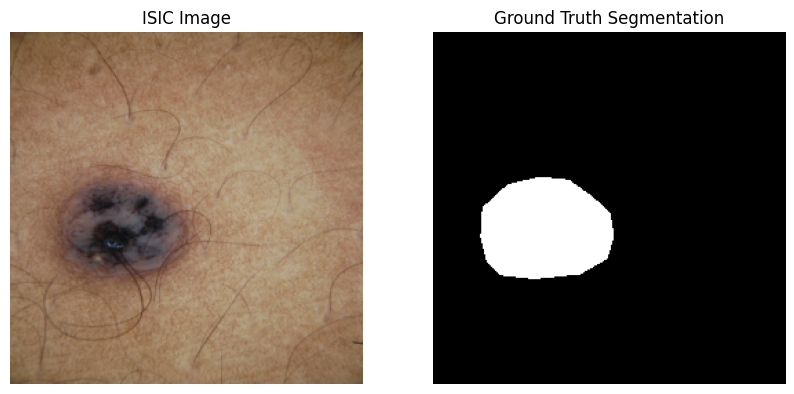

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import torch
img, mask = train_ds[0]

print("Image shape:", img.shape)
print("Mask shape:", mask.shape)
print("Mask unique values:", torch.unique(mask))

# Undo ImageNet normalization for visualization
image = img.permute(1, 2, 0).numpy()

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

image = image * std + mean
image = np.clip(image, 0, 1)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("ISIC Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask.squeeze().numpy(), cmap="gray")
plt.title("Ground Truth Segmentation")
plt.axis("off")

plt.show()

In [38]:
# import torch

# print("CUDA available:", torch.cuda.is_available())

# if torch.cuda.is_available():
#     print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: Tesla T4


In [21]:
# import gc
# import torch

# gc.collect()
# torch.cuda.empty_cache()

In [16]:
!python train.py \
    --data_root /kaggle/working/ISIC2018_small \
    --out_dir /kaggle/working/runs/isic18_small \
    --img_size 256 \
    --num_classes 1 \
    --base_dim 64 \
    --epochs 5 \
    --batch_size 2 \
    --val_ratio 0.1 \
    --test_ratio 0.2 \
    --num_workers 2 \
    --seed 42 

Using device: cuda
train=350 val=50 test=100
Model params: 15.90M
epoch 1/5 step 20/175 loss 0.5823 lr 0.001000
epoch 1/5 step 40/175 loss 0.4888 lr 0.001000
epoch 1/5 step 60/175 loss 0.4725 lr 0.001000
epoch 1/5 step 80/175 loss 0.4509 lr 0.001000
epoch 1/5 step 100/175 loss 0.4355 lr 0.001000
epoch 1/5 step 120/175 loss 0.4267 lr 0.001000
epoch 1/5 step 140/175 loss 0.4194 lr 0.001000
epoch 1/5 step 160/175 loss 0.4101 lr 0.001000
== epoch 1 done in 127.4s, train_loss=0.4095 ==
  eval: mIoU=55.11 DSC=71.06 Acc=90.18 Sen=72.17 Spe=93.79
  new best mIoU: 55.11, checkpoint saved.
epoch 2/5 step 20/175 loss 0.2967 lr 0.000905
epoch 2/5 step 40/175 loss 0.3439 lr 0.000905
epoch 2/5 step 60/175 loss 0.3416 lr 0.000905
epoch 2/5 step 80/175 loss 0.3435 lr 0.000905
epoch 2/5 step 100/175 loss 0.3381 lr 0.000905
epoch 2/5 step 120/175 loss 0.3541 lr 0.000905
epoch 2/5 step 140/175 loss 0.3717 lr 0.000905
epoch 2/5 step 160/175 loss 0.3563 lr 0.000905
== epoch 2 done in 126.0s, train_loss=0.3

In [18]:
import os

for root, dirs, files in os.walk("/kaggle/working"):
    for file in files:
        if file == "best.pth":
            print(os.path.join(root, file))

/kaggle/working/runs/isic18_small/best.pth


Device: cuda
Model loaded successfully
Best validation mIoU: 68.30726070091909
Test images: 100


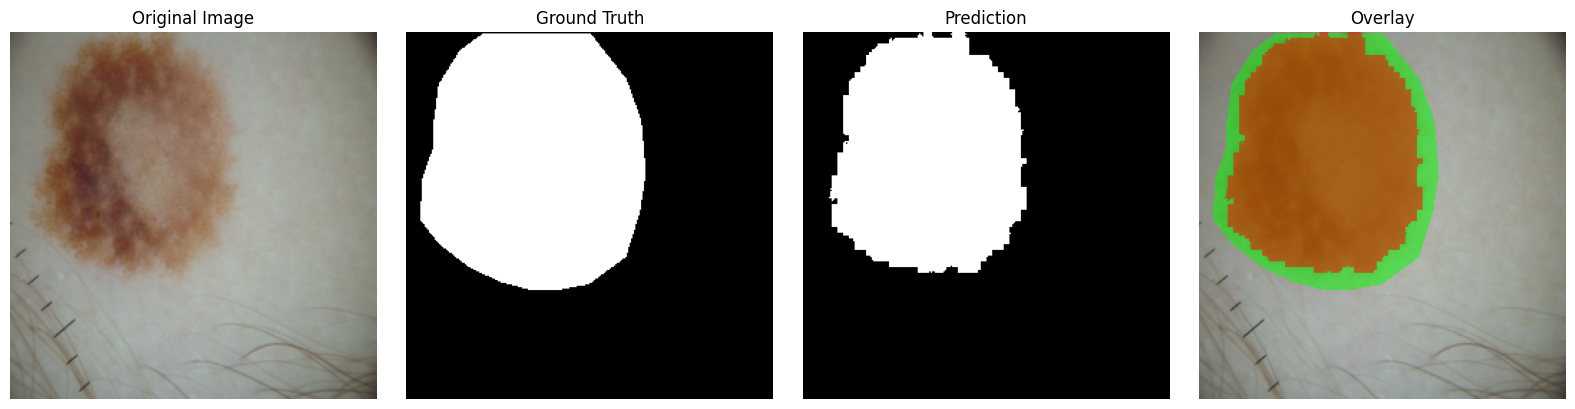

Image: ISIC_0010238.jpg


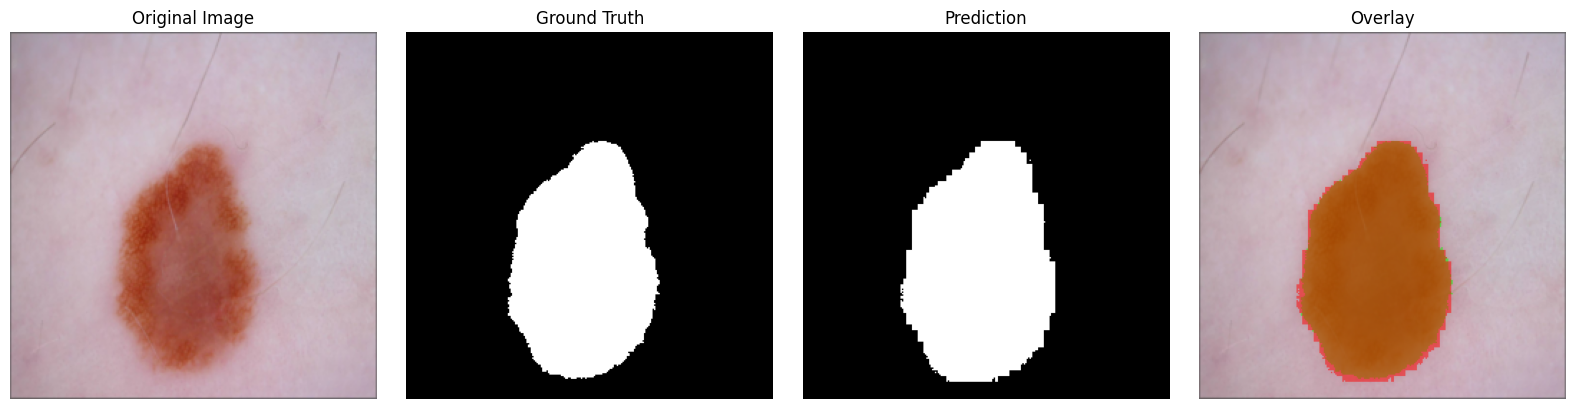

Image: ISIC_0000057.jpg


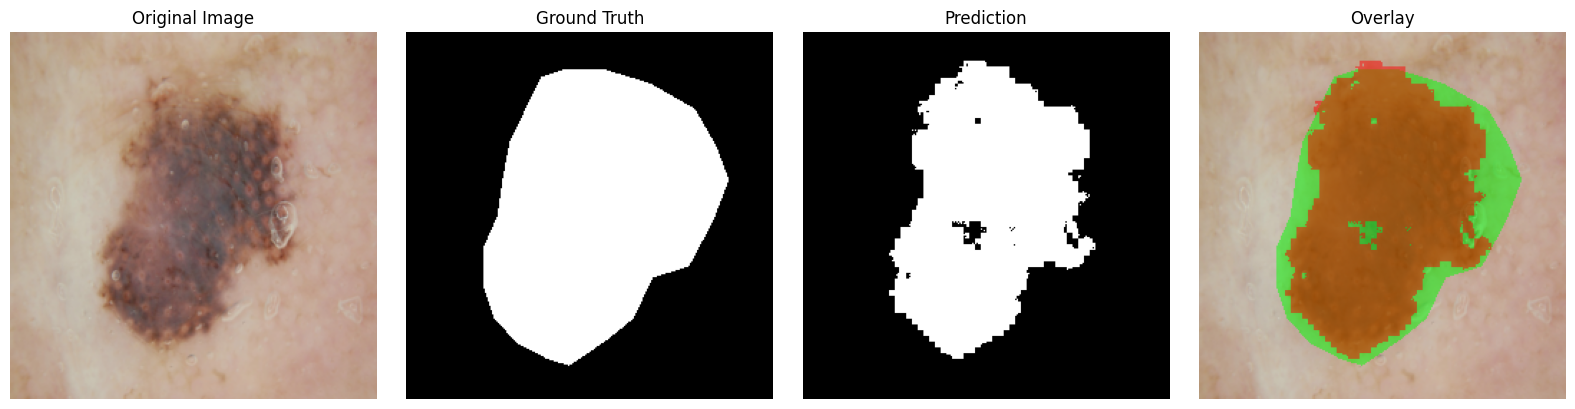

Image: ISIC_0010332.jpg


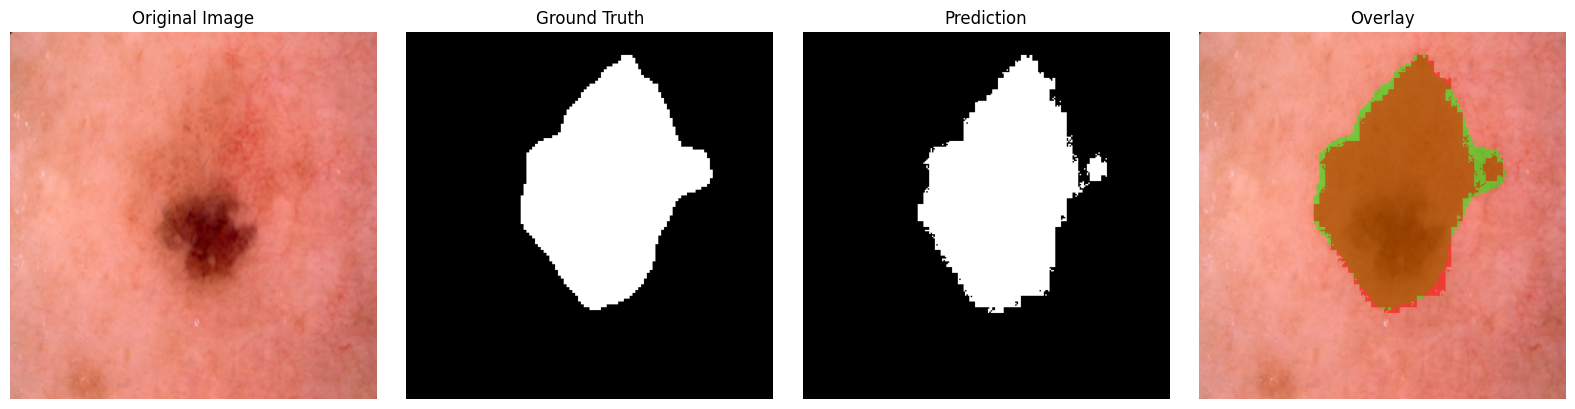

Image: ISIC_0014849.jpg


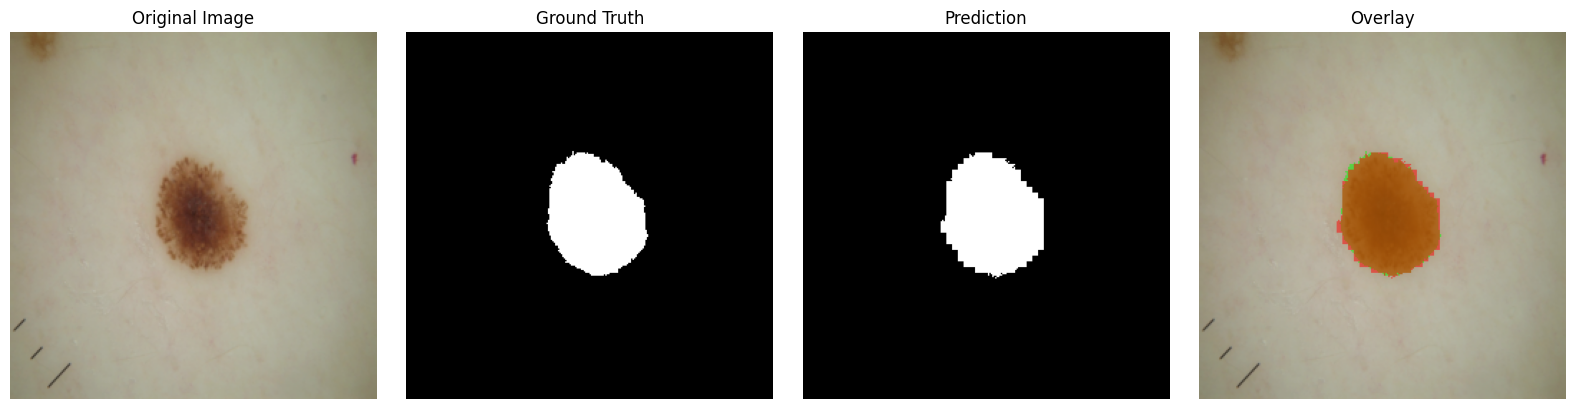

Image: ISIC_0010089.jpg


In [19]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

from model import build_scm_unet
from dataset import SegmentationDataset


# =========================
# Paths
# =========================

DATA_ROOT = "/kaggle/working/ISIC2018_small"

CHECKPOINT = "/kaggle/working/runs/isic18_small/best.pth"

IMAGE_DIR = os.path.join(DATA_ROOT, "images")
MASK_DIR = os.path.join(DATA_ROOT, "masks")


# =========================
# Device
# =========================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)


# =========================
# Load checkpoint
# =========================

checkpoint = torch.load(
    CHECKPOINT,
    map_location=device
)

model = build_scm_unet(
    num_classes=1,
    base_dim=64,
    patch_size=4,
    d_state=16
).to(device)

model.load_state_dict(checkpoint["model"])
model.eval()

print("Model loaded successfully")
print("Best validation mIoU:", checkpoint.get("best_miou", "N/A"))


# =========================
# Recreate the same test split
# =========================

from dataset import make_splits

_, _, test_files = make_splits(
    IMAGE_DIR,
    val_ratio=0.1,
    test_ratio=0.2,
    seed=42
)

print("Test images:", len(test_files))


# =========================
# Dataset
# =========================

test_dataset = SegmentationDataset(
    IMAGE_DIR,
    MASK_DIR,
    file_list=test_files,
    img_size=256,
    augment=False
)


# =========================
# Select images to visualize
# =========================

num_samples = 5

indices = np.linspace(
    0,
    len(test_dataset) - 1,
    num_samples,
    dtype=int
)


# =========================
# Visualization
# =========================

for idx in indices:

    # Get processed image and mask
    image_tensor, mask_tensor = test_dataset[idx]

    input_tensor = image_tensor.unsqueeze(0).to(device)

    # Prediction
    with torch.no_grad():
        logits = model(input_tensor)
        probability = torch.sigmoid(logits)

    prediction = (probability > 0.5).float()

    # -------------------------
    # Convert image back
    # -------------------------

    image = image_tensor.numpy().transpose(1, 2, 0)

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    image = image * std + mean
    image = np.clip(image, 0, 1)

    # -------------------------
    # Masks
    # -------------------------

    ground_truth = mask_tensor.squeeze().numpy()
    prediction = prediction.squeeze().cpu().numpy()

    # -------------------------
    # Overlay
    # -------------------------

    overlay = image.copy()

    # Ground truth boundary
    overlay[ground_truth > 0.5] = (
        0.5 * overlay[ground_truth > 0.5] +
        0.5 * np.array([0, 1, 0])
    )

    # Prediction
    overlay[prediction > 0.5] = (
        0.5 * overlay[prediction > 0.5] +
        0.5 * np.array([1, 0, 0])
    )

    # -------------------------
    # Plot
    # -------------------------

    plt.figure(figsize=(16, 4))

    plt.subplot(1, 4, 1)
    plt.imshow(image)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.imshow(ground_truth, cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.imshow(prediction, cmap="gray")
    plt.title("Prediction")
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.imshow(overlay)
    plt.title("Overlay")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    print("Image:", test_files[idx])

In [21]:
import csv
import os
import torch
import numpy as np

from dataset import SegmentationDataset, make_splits


# =========================
# Paths
# =========================

DATA_ROOT = "/kaggle/working/ISIC2018_small"

CHECKPOINT = "/kaggle/working/runs/isic18_small/best.pth"

OUTPUT_CSV = "/kaggle/working/isic18_test_results.csv"

IMAGE_DIR = os.path.join(DATA_ROOT, "images")
MASK_DIR = os.path.join(DATA_ROOT, "masks")


# =========================
# Test split
# =========================

_, _, test_files = make_splits(
    IMAGE_DIR,
    val_ratio=0.1,
    test_ratio=0.2,
    seed=42
)

test_dataset = SegmentationDataset(
    IMAGE_DIR,
    MASK_DIR,
    file_list=test_files,
    img_size=256,
    augment=False
)


# =========================
# Evaluation
# =========================

model.eval()

results = []

eps = 1e-7

with torch.no_grad():

    for idx in range(len(test_dataset)):

        image, mask = test_dataset[idx]

        image = image.unsqueeze(0).to(device)
        mask = mask.unsqueeze(0).to(device)

        logits = model(image)
        probability = torch.sigmoid(logits)

        prediction = (probability > 0.5).float()

        # Flatten
        pred = prediction.view(-1)
        target = mask.view(-1)

        TP = ((pred == 1) & (target == 1)).sum().item()
        TN = ((pred == 0) & (target == 0)).sum().item()
        FP = ((pred == 1) & (target == 0)).sum().item()
        FN = ((pred == 0) & (target == 1)).sum().item()

        iou = TP / (TP + FP + FN + eps)

        dice = (
            2 * TP /
            (2 * TP + FP + FN + eps)
        )

        accuracy = (
            (TP + TN) /
            (TP + TN + FP + FN + eps)
        )

        sensitivity = (
            TP /
            (TP + FN + eps)
        )

        specificity = (
            TN /
            (TN + FP + eps)
        )

        results.append([
            test_files[idx],
            iou,
            dice,
            accuracy,
            sensitivity,
            specificity
        ])


# =========================
# Save CSV
# =========================

with open(OUTPUT_CSV, "w", newline="") as f:

    writer = csv.writer(f)

    writer.writerow([
        "image",
        "IoU",
        "Dice",
        "Accuracy",
        "Sensitivity",
        "Specificity"
    ])

    writer.writerows(results)


print("Saved:", OUTPUT_CSV)

Saved: /kaggle/working/isic18_test_results.csv


In [25]:
%%writefile /kaggle/working/SCM_UNet/eval.py
"""
Standalone evaluation / inference script for a trained SCM-UNet checkpoint.

Example:
    python eval.py --data_root /path/to/ISIC2018 --ckpt runs/isic18/best.pth \
        --img_size 256 --save_preds preds/isic18
"""

import argparse
import os

import numpy as np
import torch
from PIL import Image
from torch.utils.data import DataLoader

from model import build_scm_unet
from dataset import build_datasets
from metrics import ConfusionMeter


def get_args():
    p = argparse.ArgumentParser(description='Evaluate Mamba-UNet')
    p.add_argument('--data_root', type=str, required=True)
    p.add_argument('--ckpt', type=str, required=True)
    p.add_argument('--img_size', type=int, default=256)
    p.add_argument('--batch_size', type=int, default=16)
    p.add_argument('--num_workers', type=int, default=4)
    p.add_argument('--threshold', type=float, default=0.5)
    p.add_argument('--save_preds', type=str, default=None,
                    help='If set, save predicted masks (as PNGs) to this directory')
    p.add_argument('--val_ratio', type=float, default=0.1)
    p.add_argument('--test_ratio', type=float, default=0.2)
    p.add_argument('--seed', type=int, default=42)
    return p.parse_args()


def main():
    args = get_args()
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    ckpt = torch.load(args.ckpt, map_location=device)
    train_args = ckpt.get('args', {})
    base_dim = train_args.get('base_dim', 64)
    d_state = train_args.get('d_state', 16)
    patch_size = train_args.get('patch_size', 4)
    num_classes = train_args.get('num_classes', 1)

    model = build_scm_unet(
        num_classes=num_classes,
        base_dim=base_dim,
        patch_size=patch_size,
        d_state=d_state
    ).to(device)
    model.load_state_dict(ckpt['model'])
    model.eval()

    _, _, test_ds = build_datasets(
        args.data_root, img_size=args.img_size,
        val_ratio=args.val_ratio, test_ratio=args.test_ratio, seed=args.seed)
    test_loader = DataLoader(test_ds, batch_size=args.batch_size, shuffle=False,
                              num_workers=args.num_workers)

    if args.save_preds:
        os.makedirs(args.save_preds, exist_ok=True)

    meter = ConfusionMeter()
    idx = 0
    with torch.no_grad():
        for imgs, masks in test_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            logits = model(imgs)
            probs = torch.sigmoid(logits)
            preds = (probs > args.threshold).float()
            meter.update(preds, masks)

            if args.save_preds:
                preds_np = (preds.cpu().numpy()[:, 0] * 255).astype(np.uint8)
                for b in range(preds_np.shape[0]):
                    fname = test_ds.files[idx]
                    stem = os.path.splitext(fname)[0]
                    Image.fromarray(preds_np[b]).save(
                        os.path.join(args.save_preds, f'{stem}_pred.png'))
                    idx += 1

    metrics = meter.compute()
    print('Test set results:')
    for k, v in metrics.items():
        print(f'  {k}: {v:.2f}')


if __name__ == '__main__':
    main()


Overwriting /kaggle/working/SCM_UNet/eval.py


In [32]:
%cd /kaggle/working/SCM_UNet

!find /kaggle/working/runs -name "best.pth"

/kaggle/working/SCM_UNet
/kaggle/working/runs/isic18_small/best.pth


In [33]:
%cd /kaggle/working/SCM_UNet

!python eval.py \
    --data_root /kaggle/working/ISIC2018_small \
    --ckpt /kaggle/working/runs/isic18_small/best.pth \
    --img_size 256 \
    --batch_size 16 \
    --save_preds /kaggle/working/SCM_UNet/preds/isic18_small

/kaggle/working/SCM_UNet
Test set results:
  mIoU: 72.94
  DSC: 84.35
  Acc: 93.21
  Sen: 78.35
  Spe: 97.74
